In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telco_churn.csv to telco_churn.csv


In [ ]:
df = pd.read_csv("telco_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# DATA CLEANING
# CONVERTING TOTAL CHARGES INTO NUMERIC COLUMN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# HANDLE MISSING VALUES
df.isnull().sum()
df.dropna(inplace = True)

In [ ]:
# TARGET COLUMN
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
# CONVERT TARGET COLUMN YES NO
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

 **EXPLORATORY DATA ANALYSIS**

/tmp/ipykernel_11187/486553737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#F44336'])


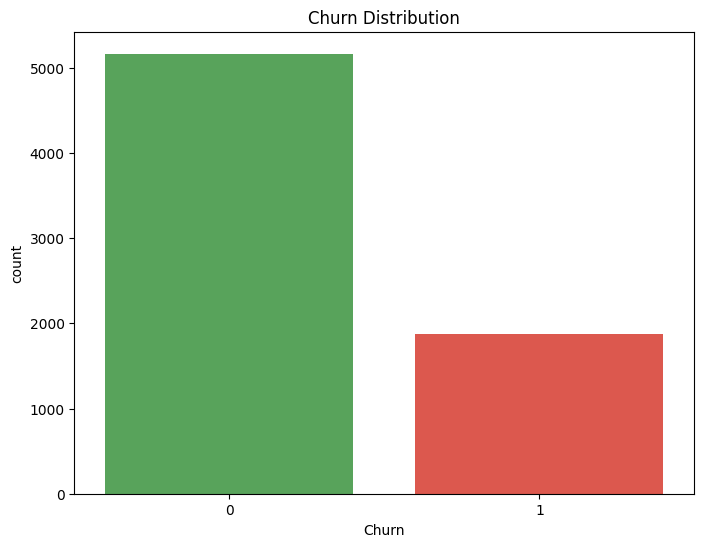

In [ ]:
# 1 CHURN DISTRIBUTION
plt.figure(figsize=(8,6))
sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Churn Distribution')
plt.show()

Short Insights

~73% customers retained, ~27% churned

Around 1 in 4 customers is leaving

Dataset is imbalanced (more non-churn than churn)

Churn rate is significant → needs attention

Big opportunity: reducing churn can boost revenue

👉 Focus next on: contract type, tenure, and
charges to understand why customers churn.

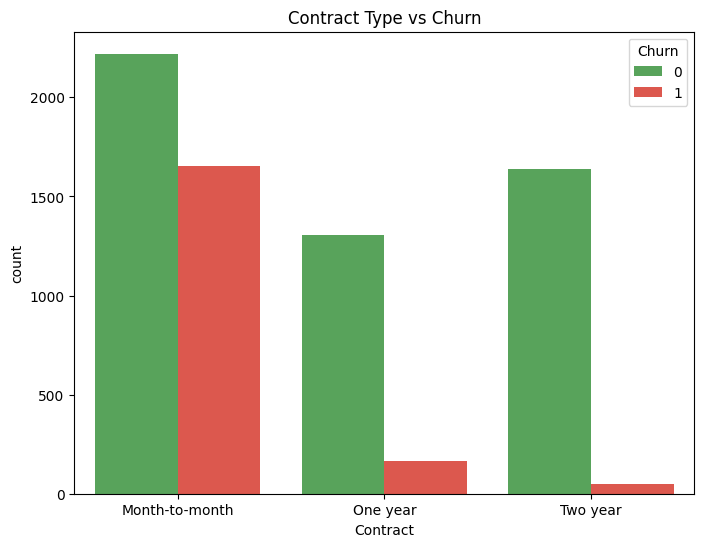

In [ ]:
# 2 📊 Contract Type vs Churn (MOST IMPORTANT)
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Contract Type vs Churn')
plt.show()

### 📊 Short Detailed Insights

* **Month-to-month contracts have the highest churn**
  → Churn is almost **as high as retention**
  👉 These customers are **high-risk**

* **One-year contracts show much lower churn**
  → Majority customers are retained
  👉 Commitment reduces churn

* **Two-year contracts have the lowest churn**
  → Almost **no customers leave**
  👉 Long-term contracts = **strong loyalty**

* **Clear pattern: Longer contract → Lower churn**
  👉 Contract duration is a **key driver of churn**

---

### 💡 Business Takeaway

Encourage users to move from **monthly → yearly plans** to significantly reduce churn.


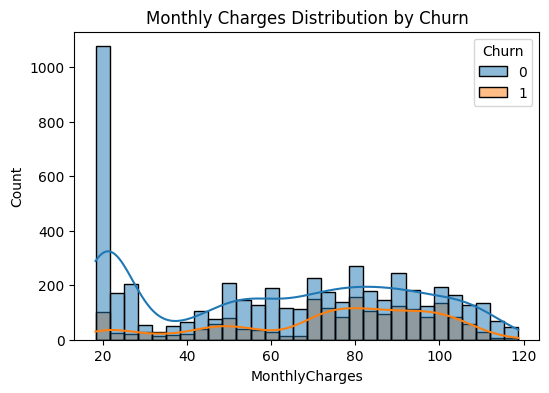

In [ ]:
# 3 monthy charges vs churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

### 📊 Insights: Monthly Charges vs Churn

* **Higher charges → higher churn**
  👉 Churned customers are concentrated in the **₹70–₹110 range**

* **Low charges customers rarely churn**
  👉 Strong retention in **₹20–₹40 range**

* **Churn distribution is shifted right**
  👉 Customers who leave tend to pay **more than average**

* **Retention spread is wider**
  👉 Non-churn customers exist across all price ranges, especially lower ones

* **Price sensitivity is a key factor**
  👉 Expensive plans increase churn risk

---

### 💡 Business Insight

Customers paying higher monthly charges are more likely to leave → focus on:

* Discounts / offers
* Better value perception
* Premium customer experience

👉 High-paying customers = **high churn risk + high revenue impact**


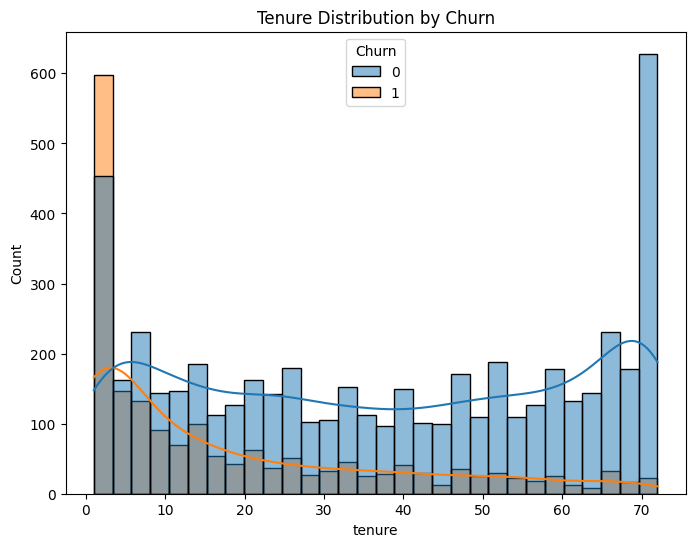

In [ ]:
# 4 📊 Tenure vs Churn
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

### 📊 Insights: Tenure vs Churn

* **New customers churn the most**
  👉 High churn in **0–10 months tenure**

* **Churn decreases as tenure increases**
  👉 Customers staying longer are **less likely to leave**

* **Long-tenure customers are highly loyal**
  👉 Very low churn after **50+ months**

* **Retention peaks at high tenure**
  👉 Majority of non-churn customers are in **60–72 months**

* **Critical risk period = early stage**
  👉 First few months are **make-or-break**

---

### 💡 Business Insight

Focus on **early customer experience (first 3–6 months)**:

* Onboarding improvements
* Customer support
* Engagement strategies

👉 Retain early → long-term loyal customers 🚀


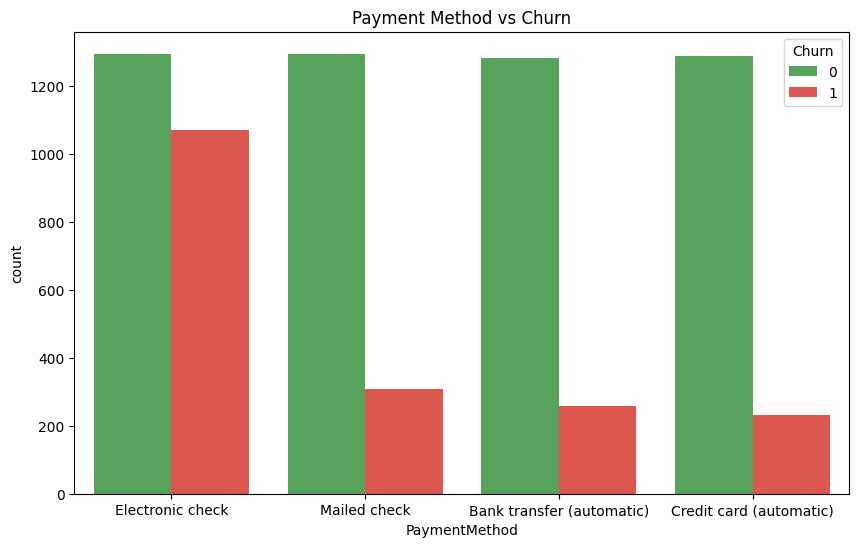

In [ ]:
# 5 payment method vs churn
plt.figure(figsize=(10,6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Payment Method vs Churn')
plt.show()

### 📊 Insights: Payment Method vs Churn

* **Electronic check has the highest churn**
  👉 Churn is **very high compared to other methods**
  👉 Major risk segment

* **Automatic payments have lowest churn**
  👉 *Bank transfer* & *credit card (auto)* show **strong retention**
  👉 Auto-pay users are more stable

* **Mailed check has moderate churn**
  👉 Better than electronic check but worse than auto-pay

* **Clear pattern: Manual payment → Higher churn**
  👉 Automatic payment → **lower churn**

---

### 💡 Business Insight

Encourage customers to switch to **auto-payment methods**:

* Offer discounts for auto-pay
* Simplify payment setup

👉 Payment behavior is a **strong churn indicator** 🚀


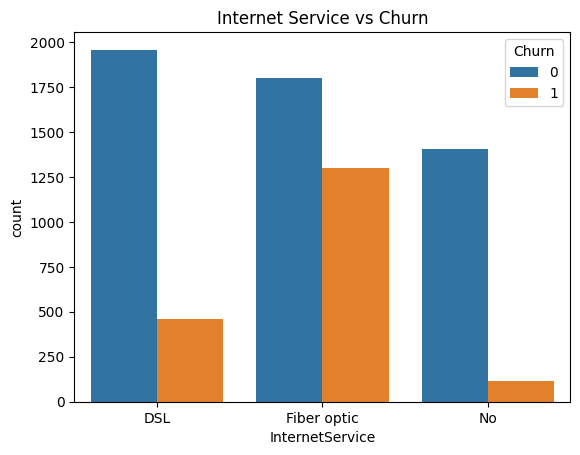

In [ ]:
# 6 INTERNET SERVICE VS CHURN
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

### 📊 Insights: Internet Service vs Churn

* **Fiber optic users have the highest churn**
  👉 Churn is **very high compared to DSL and no service**
  👉 High-value but **high-risk segment**

* **DSL users show moderate churn**
  👉 Better retention than fiber users
  👉 More stable customer base

* **Customers with no internet have lowest churn**
  👉 Very few customers leave
  👉 Possibly low expectations or basic usage

* **Clear pattern: Better service ≠ lower churn**
  👉 Fiber users may face **high cost or service issues**

---

### 💡 Business Insight

Focus on **fiber optic customers**:

* Improve service quality
* Address pricing concerns
* Provide better support

👉 Retaining fiber users is critical since they are **high revenue but high churn** 🚀


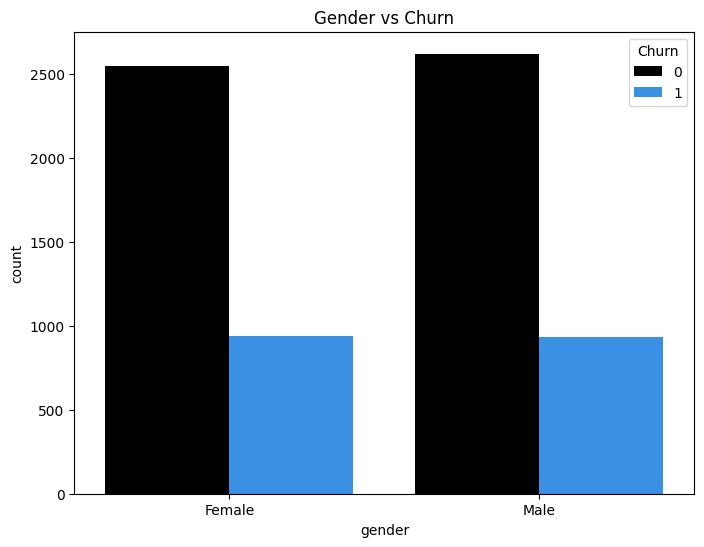

In [ ]:
# 7 GENDER VS CHURN
plt.figure(figsize=(8,6))
sns.countplot(x='gender', hue='Churn', data=df,
              palette=['#000000', '#1E90FF'])
plt.title('Gender vs Churn')
plt.show()

### 📊 Insights: Gender vs Churn

* **Churn is almost equal for both genders**
  👉 Male and Female customers show **very similar churn patterns**

* **No strong gender impact**
  👉 Gender is **not a key driver of churn**

* **Slightly higher male count**
  👉 More male customers overall, but churn % remains similar

* **Retention pattern is consistent**
  👉 Both genders have **similar retention behavior**

---

### 💡 Business Insight

* Gender-based targeting is **not effective**
* Focus more on:

  * Contract type
  * Tenure
  * Monthly charges

👉 These factors influence churn much more 🚀


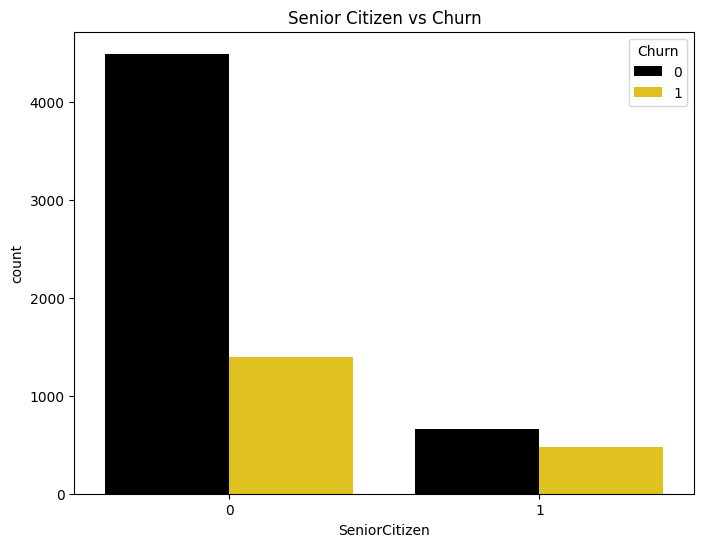

In [ ]:
# 8 📊 Senior Citizen vs Churn
plt.figure(figsize=(8,6))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df,
              palette=['#000000', '#FFD700'])
plt.title('Senior Citizen vs Churn')
plt.show()

### 📊 Insights: Senior Citizen vs Churn

* **Senior citizens have higher churn rate**
  👉 Proportion of churn is **much higher for senior (1)** compared to non-senior (0)

* **Non-senior customers dominate overall**
  👉 Majority customers are non-senior, but their churn % is lower

* **Senior segment is high-risk**
  👉 Even with fewer customers, churn is **relatively high**

* **Retention is stronger in non-senior group**
  👉 Most non-senior customers stay longer

---

### 💡 Business Insight

Focus on **senior citizens**:

* Better customer support
* Simpler plans/pricing
* Personalized assistance

👉 Senior customers = **smaller group but higher churn risk** 🚀


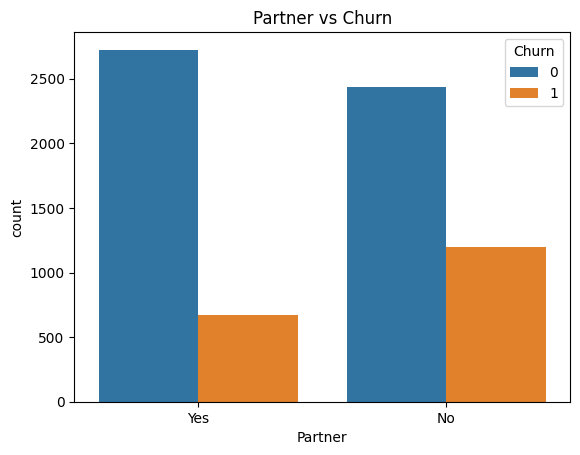

In [ ]:
# 9 PARTNER VS CHURN
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Partner vs Churn")
plt.show()

### 📊 Insights: Partner vs Churn

* **Customers without a partner churn more**
  👉 “No partner” group shows **significantly higher churn**

* **Customers with a partner are more loyal**
  👉 Higher retention in **partner = Yes**

* **Partner status impacts stability**
  👉 Having a partner likely indicates **more stable usage/long-term commitment**

* **Clear behavioral pattern**
  👉 Single customers = **higher churn risk**

---

### 💡 Business Insight

Target customers without partners:

* Personalized offers
* Engagement campaigns
* Flexible plans

👉 “No partner” segment = **key churn risk group** 🚀


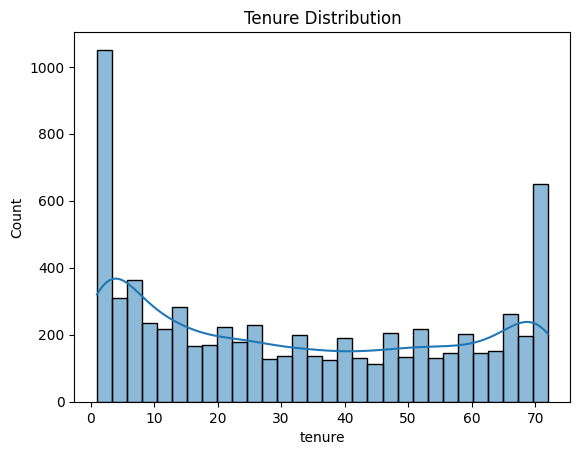

In [ ]:
# 10 TENURE DISTRIBUTION
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

### 📊 Insights: Tenure Distribution

* **High number of new customers (0–5 months)**
  👉 Indicates strong acquisition but also **early-stage risk**

* **Spike at very high tenure (65–72 months)**
  👉 Many **long-term loyal customers**

* **Middle tenure (10–50 months) is relatively stable**
  👉 No extreme peaks → steady customer base

* **U-shaped pattern**
  👉 More customers at **start and end**, fewer in the middle

* **Customer lifecycle is clear**
  👉 Early stage (risky) → mid stage (stable) → long-term (loyal)

---

### 💡 Business Insight

* Focus on **early retention (first few months)**
* Maintain engagement to move users into **long-term loyal segment**

👉 Goal: Convert new users → long-term customers 🚀


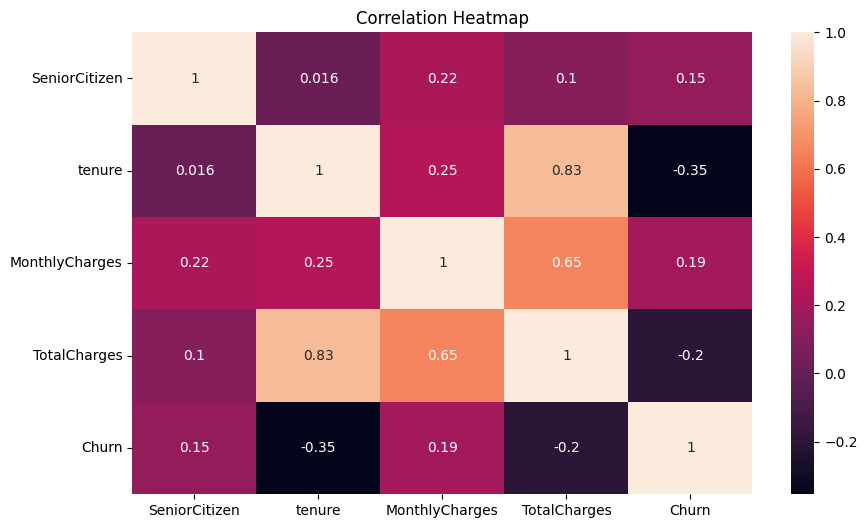

In [ ]:
# 11 CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### 📊 Insights: Correlation Heatmap

* **Tenure has strongest negative correlation with churn (-0.35)**
  👉 Longer stay → **less likely to churn** (very important feature)

* **Monthly Charges positively correlated with churn (0.19)**
  👉 Higher charges → **higher churn risk**

* **Total Charges negatively correlated with churn (-0.20)**
  👉 High total spenders are **more loyal customers**

* **Strong correlation: Tenure vs Total Charges (0.83)**
  👉 Logical: longer customers → **more total spend**

* **Monthly vs Total Charges (0.65)**
  👉 Higher monthly plans → higher total revenue

* **Senior Citizen has weak correlation (0.15)**
  👉 Slight impact but **not a strong driver**

---

### 💡 Business Insight

* **Top churn drivers:** Tenure (↓), Monthly Charges (↑)
* Focus on:

  * Retaining **new customers (low tenure)**
  * Managing **high monthly cost perception**

👉 Tenure is the **most important feature for churn prediction** 🚀


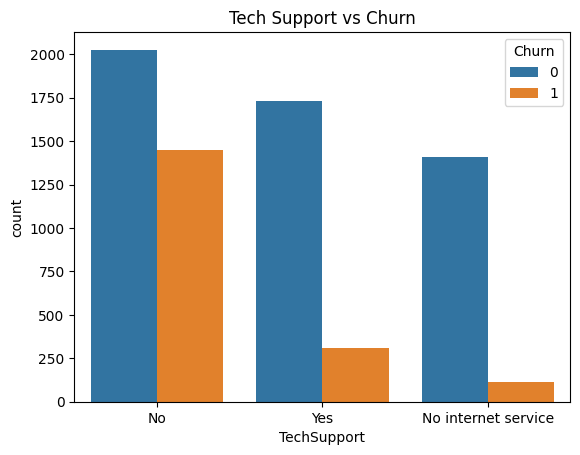

In [ ]:
# 12 TECH SUPPORT VS CHURN
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Churn")
plt.show()

### 📊 Insights: Tech Support vs Churn

* **No tech support → highest churn**
  👉 Customers without support show **very high churn**

* **Having tech support reduces churn significantly**
  👉 “Yes” group has **much better retention**

* **No internet service → lowest churn**
  👉 Minimal churn, likely low dependency users

* **Support availability impacts loyalty**
  👉 Customers with help available are **more satisfied & stable**

---

### 💡 Business Insight

* Promote **tech support services**
* Offer **free trials / bundled support plans**
* Improve **customer issue resolution**

👉 Tech support = **strong churn reduction factor** 🚀


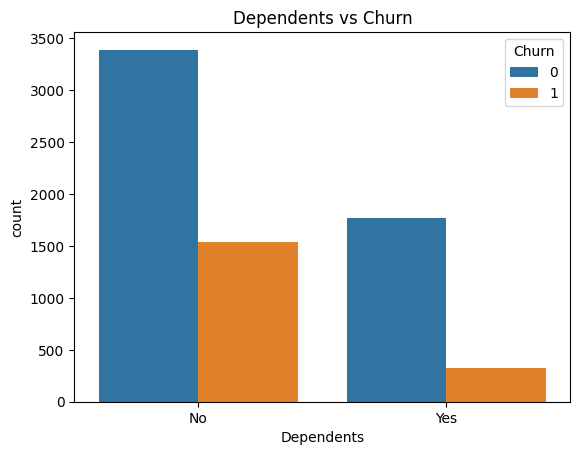

In [ ]:
# 13 DEPENDENTS VS CHURN
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Dependents vs Churn")
plt.show()

### 📊 Insights: Dependents vs Churn

* **Customers without dependents churn more**
  👉 “No dependents” group shows **higher churn count**

* **Customers with dependents are more loyal**
  👉 Lower churn in **dependents = Yes**

* **Family responsibility = stability**
  👉 Customers with dependents likely prefer **long-term continuity**

* **Clear pattern**
  👉 No dependents → **higher churn risk**

---

### 💡 Business Insight

* Target customers without dependents:

  * Engagement offers
  * Flexible plans
  * Personalized deals

👉 Customers with dependents = **more stable segment** 🚀


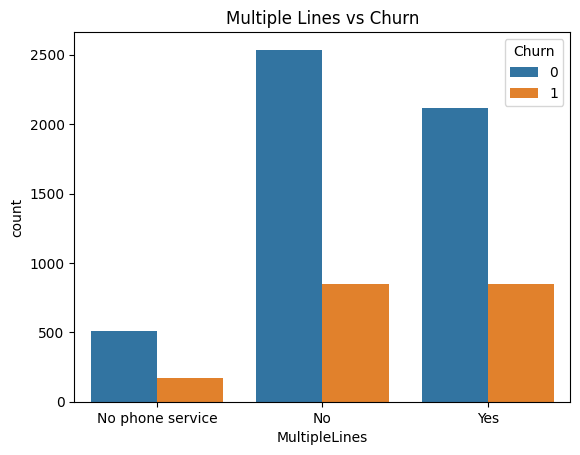

In [ ]:
# 14 MULTIPLE LINES VS CHURN
sns.countplot(x='MultipleLines', hue='Churn', data=df)
plt.title("Multiple Lines vs Churn")
plt.show()

### 📊 Insights: Multiple Lines vs Churn

* **Customers without multiple lines churn slightly more**
  👉 “No” group shows **higher churn than “Yes”**

* **Multiple lines users are a bit more stable**
  👉 Having multiple connections → **lower churn tendency**

* **No phone service → low churn**
  👉 Small segment, less impact on overall churn

* **Weak to moderate impact feature**
  👉 Difference exists but **not very strong**

---

### 💡 Business Insight

* Upsell customers to **multiple lines / bundled plans**
* Create **family or combo offers**

👉 Bundled services = **better retention & customer stickiness** 🚀


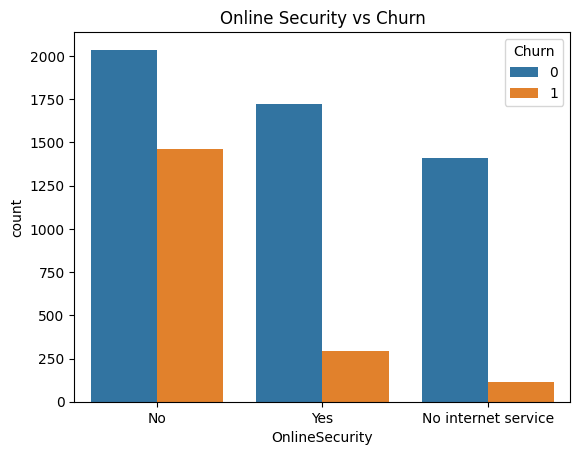

In [ ]:
# 15 ONLINE SECURITY VS CHURN
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Online Security vs Churn")
plt.show()

### 📊 Insights: Online Security vs Churn

* **No online security → highest churn**
  👉 Customers without security show **very high churn**

* **Having online security reduces churn sharply**
  👉 “Yes” group has **strong retention**

* **No internet service → very low churn**
  👉 Small, stable segment

* **Security adds customer confidence**
  👉 Users with protection feel **safer and more satisfied**

* **Strong churn driver**
  👉 Online security is a **key factor influencing churn**

---

### 💡 Business Insight

* Bundle **online security with plans**
* Offer **free trials / discounts**
* Educate users about benefits

👉 Security services = **powerful churn reduction strategy** 🚀
